In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile

with zipfile.ZipFile('/content/degraded_photos.zip', 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
import os

clean_path = "/content/dataset/degraded_photos/clean_images"
degraded_path = "/content/dataset/degraded_photos/degraded_images"

clean_images = os.listdir(clean_path)
degraded_images = os.listdir(degraded_path)

print("Number of clean images:", len(clean_images))
print("Number of degraded images:", len(degraded_images))

Number of clean images: 515
Number of degraded images: 515


In [ ]:
import os
import cv2
import numpy as np

clean_path = "/content/dataset/degraded_photos/clean_images"
degraded_path = "/content/dataset/degraded_photos/degraded_images"

IMG_SIZE = 256

clean_images = []
degraded_images = []

clean_files = sorted(os.listdir(clean_path))
degraded_files = sorted(os.listdir(degraded_path))

for c_img, d_img in zip(clean_files, degraded_files):

    clean = cv2.imread(os.path.join(clean_path, c_img))
    degraded = cv2.imread(os.path.join(degraded_path, d_img))

    clean = cv2.resize(clean, (IMG_SIZE, IMG_SIZE))
    degraded = cv2.resize(degraded, (IMG_SIZE, IMG_SIZE))

    clean_images.append(clean)
    degraded_images.append(degraded)

clean_images = np.array(clean_images) / 255.0
degraded_images = np.array(degraded_images) / 255.0

print("Clean Images Shape:", clean_images.shape)
print("Degraded Images Shape:", degraded_images.shape)

Clean Images Shape: (515, 256, 256, 3)
Degraded Images Shape: (515, 256, 256, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    degraded_images,
    clean_images,
    test_size=0.2,
    random_state=42
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (412, 256, 256, 3)
Testing images: (103, 256, 256, 3)


In [ ]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add

def residual_block(x, filters):

    shortcut = x

    x = Conv2D(filters, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, (3,3), padding="same")(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

In [ ]:
from tensorflow.keras.layers import Input, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model

def build_res_unet(input_shape=(256,256,3)):

    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3,3), padding="same", activation="relu")(inputs)
    c1 = residual_block(c1, 64)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(128, (3,3), padding="same", activation="relu")(p1)
    c2 = residual_block(c2, 128)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(256, (3,3), padding="same", activation="relu")(p2)
    c3 = residual_block(c3, 256)
    p3 = MaxPooling2D((2,2))(c3)

    # Bottleneck
    b = Conv2D(512, (3,3), padding="same", activation="relu")(p3)
    b = residual_block(b, 512)

    # Decoder
    u1 = UpSampling2D((2,2))(b)
    u1 = Concatenate()([u1, c3])
    c4 = Conv2D(256, (3,3), padding="same", activation="relu")(u1)
    c4 = residual_block(c4, 256)

    u2 = UpSampling2D((2,2))(c4)
    u2 = Concatenate()([u2, c2])
    c5 = Conv2D(128, (3,3), padding="same", activation="relu")(u2)
    c5 = residual_block(c5, 128)

    u3 = UpSampling2D((2,2))(c5)
    u3 = Concatenate()([u3, c1])
    c6 = Conv2D(64, (3,3), padding="same", activation="relu")(u3)
    c6 = residual_block(c6, 64)

    outputs = Conv2D(3, (1,1), activation="sigmoid")(c6)

    model = Model(inputs, outputs)

    return model


model = build_res_unet()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 11,703,299 (44.64 MB)

 Trainable params: 11,697,667 (44.62 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=8
)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - loss: 0.0206 - mae: 0.1028 - val_loss: 0.0552 - val_mae: 0.1969
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 671ms/step - loss: 0.0103 - mae: 0.0770 - val_loss: 0.0503 - val_mae: 0.1873
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 667ms/step - loss: 0.0076 - mae: 0.0664 - val_loss: 0.0474 - val_mae: 0.1817
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 674ms/step - loss: 0.0077 - mae: 0.0666 - val_loss: 0.0464 - val_mae: 0.1791
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 675ms/step - loss: 0.0070 - mae: 0.0640 - val_loss: 0.0432 - val_mae: 0.1723
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 672ms/step - loss: 0.0062 - mae: 0.0603 - val_loss: 0.0391 - val_mae: 0.1633
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 671ms/step - loss: 0.0063 - mae: 0.0607 - val_loss: 0.0326 - val_mae: 0.1494
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 668ms/step - loss: 0.0056 - mae: 0.0574 - val_loss: 0.0286 - val_mae: 0.1385
Epoch 9/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 669ms/st

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


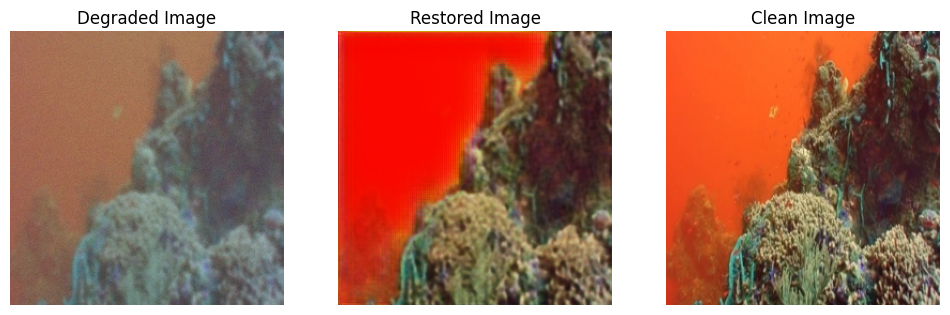

In [ ]:
import matplotlib.pyplot as plt
import random

# pick a random test image
idx = random.randint(0, len(X_test)-1)

degraded = X_test[idx]
clean = y_test[idx]

# model prediction
restored = model.predict(degraded[np.newaxis, ...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Degraded Image")
plt.imshow(degraded)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Restored Image")
plt.imshow(restored)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Clean Image")
plt.imshow(clean)
plt.axis("off")

plt.show()

In [ ]:
model.save("resunet_image_restoration_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
!pip install ultralytics

from ultralytics import YOLO

# load pretrained YOLOv8 model
yolo_model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 model loaded successfully!


In [ ]:
import random
import numpy as np
import cv2

idx = random.randint(0, len(X_test)-1)

degraded = X_test[idx]

# restore image using Res-U Net
restored = model.predict(np.expand_dims(degraded, axis=0))[0]

# convert image to 0-255 format for YOLO
restored_img = (restored * 255).astype("uint8")

cv2.imwrite("restored_image.jpg", restored_img)

# run YOLO detection
results = yolo_model("restored_image.jpg", show=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/restored_image.jpg: 640x640 1 bear, 18.4ms
Speed: 21.6ms preprocess, 18.4ms inference, 90.1ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
import zipfile

zip_path = "/content/trash_ICRA19.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/trashcan_dataset")

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
import os

base_path = "/content/trashcan_dataset"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/content/trashcan_dataset


In [ ]:
import os

base = "/content/trashcan_dataset/trash_ICRA19/dataset"

folders = [
    f"{base}/train/images",
    f"{base}/train/labels",
    f"{base}/val/images",
    f"{base}/val/labels"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [ ]:
import os
import shutil

val_path = "/content/trashcan_dataset/trash_ICRA19/dataset/val"

for file in os.listdir(val_path):

    full_path = os.path.join(val_path, file)

    if file.endswith(".jpg"):
        shutil.move(full_path, os.path.join(val_path, "images", file))

    elif file.endswith(".txt"):
        shutil.move(full_path, os.path.join(val_path, "labels", file))

print("Validation images and labels moved successfully")

Validation images and labels moved successfully


In [ ]:
import os
import shutil

train_path = "/content/trashcan_dataset/trash_ICRA19/dataset/train"

for file in os.listdir(train_path):

    full_path = os.path.join(train_path, file)

    if file.endswith(".jpg"):
        shutil.move(full_path, os.path.join(train_path, "images", file))

    elif file.endswith(".txt"):
        shutil.move(full_path, os.path.join(train_path, "labels", file))

print("Train images and labels moved successfully")

Train images and labels moved successfully


In [ ]:
yaml_content = """
path: /content/trashcan_dataset/trash_ICRA19/dataset

train: train/images
val: val/images

names:
  0: plastic_bag
  1: bottle
  2: sheet
  3: solid_object
  4: box
  5: metal_sheet
  6: tube
  7: glass_bottle
  8: fishing_net
  9: rope
  10: can

"""

with open("trash_can_dataset.yaml", "w") as f:
    f.write(yaml_content)

print("YAML file created successfully")

YAML file created successfully


In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="trash_can_dataset.yaml",
    epochs=40,
    imgsz=416,
    batch=4,
    patience=10
)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=trash_can_dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5f7cccb740>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
import os
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

image_folder = "/content/trashcan_dataset/trash_ICRA19/dataset/val/images"

images = sorted(os.listdir(image_folder))[:50]

image_paths = [os.path.join(image_folder, img) for img in images]

results = model.predict(
    source=image_paths,
    conf=0.05,
    save=True
)


0: 320x416 3 plastic_bags, 1.6ms
1: 320x416 3 plastic_bags, 1.6ms
2: 320x416 2 plastic_bags, 1.6ms
3: 320x416 3 plastic_bags, 1.6ms
4: 320x416 1 plastic_bag, 1.6ms
5: 320x416 3 plastic_bags, 1.6ms
6: 320x416 2 plastic_bags, 1.6ms
7: 320x416 3 plastic_bags, 1.6ms
8: 320x416 1 plastic_bag, 1.6ms
9: 320x416 3 plastic_bags, 1.6ms
10: 320x416 1 plastic_bag, 1.6ms
11: 320x416 1 plastic_bag, 1.6ms
12: 320x416 1 plastic_bag, 1.6ms
13: 320x416 2 plastic_bags, 1.6ms
14: 320x416 1 plastic_bag, 1.6ms
15: 320x416 2 plastic_bags, 1.6ms
16: 320x416 2 plastic_bags, 2 bottles, 1.6ms
17: 320x416 2 plastic_bags, 1.6ms
18: 320x416 2 plastic_bags, 1.6ms
19: 320x416 1 plastic_bag, 1.6ms
20: 320x416 1 plastic_bag, 1.6ms
21: 320x416 1 plastic_bag, 1.6ms
22: 320x416 1 plastic_bag, 1.6ms
23: 320x416 1 plastic_bag, 1.6ms
24: 320x416 2 plastic_bags, 1.6ms
25: 320x416 5 plastic_bags, 1.6ms
26: 320x416 3 plastic_bags, 1.6ms
27: 320x416 2 plastic_bags, 1 bottle, 1.6ms
28: 320x416 3 bottles, 1.6ms
29: 320x416 1 plas

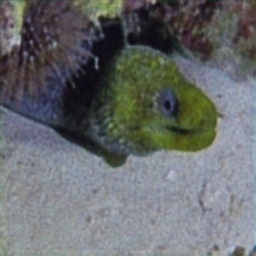

In [ ]:
from IPython.display import Image, display
display(Image("/content/restored_image.jpg"))